In [4]:
# If you already have these (recent versions), you can skip.
# In Windows notebooks, prefer %pip over !pip.
%pip install -q "transformers>=4.41.0" "datasets>=2.18.0" evaluate sacrebleu sentencepiece accelerate


In [5]:
%pip install -q bert-score sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.3 MB/s eta 0:00:00


In [6]:
# Check disk usage of directories and files in /content
!du -sh /content/*

55M	/content/sample_data


In [7]:
from sklearn.metrics import f1_score
from bert_score import score as bertscore
from sentence_transformers import SentenceTransformer
import os
import numpy as np
import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq, Seq2SeqTrainingArguments, Seq2SeqTrainer, set_seed
)
from transformers import EarlyStoppingCallback
import evaluate

# Reproducibility
SEED = 42
set_seed(SEED)

# Model choice: multilingual, robust for Telugu
MODEL_NAME = "ai4bharat/IndicBART" # you can switch to "ai4bharat/indicbart-v2" if you prefer
OUTPUT_DIR = "te_qa_supervised_mt5"

# Task: MODEL 2 — Telugu question ONLY → Telugu answer
MAX_SRC_LEN = 256
MAX_TGT_LEN = 64
BATCH_SIZE  = 8          # reduce if RAM is tight
EPOCHS      = 35
LR          = 2e-4

In [9]:
# TyDi XOR RC; we’ll keep only Telugu examples where answer_inlang is present
ds = load_dataset("coastalcph/tydi_xor_rc")

def keep_te_with_inlang(x):
    return (x.get("lang") == "te") and (x.get("answer_inlang") not in (None, "")) and (x.get("question") not in (None, ""))

ds_te = {
    "train": ds["train"].filter(keep_te_with_inlang),
    "validation": ds["validation"].filter(keep_te_with_inlang),
}
print("Telugu sizes (train/val):", len(ds_te["train"]), len(ds_te["validation"]))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.parquet:   0%|          | 0.00/6.88M [00:00<?, ?B/s]

validation.parquet:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

test.parquet:   0%|          | 0.00/4.80k [00:00<?, ?B/s]

...

Generating validation split:   0%|          | 0/3011 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/4 [00:00<?, ? examples/s]

Filter:   0%|          | 0/15343 [00:00<?, ? examples/s]

Filter:   0%|          | 0/3011 [00:00<?, ? examples/s]

Telugu sizes (train/val): 50 100


In [10]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


tokenizer_config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/832 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/1.90M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/221 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/398 [00:00<?, ?B/s]

In [11]:
%pip install -q rouge_score

  Preparing metadata (setup.py) ... done


In [12]:
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

bleu = evaluate.load("sacrebleu")
rouge = evaluate.load("rouge")

def compute_metrics(eval_preds):
    predictions, labels = eval_preds

    # Decode model outputs and labels
    # Filter out -100 from labels before decoding
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id) # Replace -100 with pad_token_id for decoding if necessary, or just filter. Filtering might be safer.
    # Let's try filtering out -100 completely instead of replacing with pad_token_id
    decoded_labels = []
    for label_seq in labels:
        # Filter out -100 and decode
        valid_label_ids = label_seq[label_seq != -100]
        decoded_labels.append(tokenizer.decode(valid_label_ids, skip_special_tokens=True))

    pred_texts = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    label_texts = decoded_labels


    # Compute BLEU (requires references as list of lists)
    # Ensure references are list of lists
    bleu_score = bleu.compute(
        predictions=pred_texts,
        references=[[ref] for ref in label_texts]
    )["score"]

    # Compute ROUGE
    rouge_result = rouge.compute(predictions=pred_texts, references=label_texts)

    # Compute Exact Match (strict match of entire strings)
    exact_match = sum(p.strip() == l.strip() for p, l in zip(pred_texts, label_texts)) / len(pred_texts)

    return {
        "exact_match": exact_match,
        "bleu": bleu_score,
        "rougeL": rouge_result["rougeL"]
    }

args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LR,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    predict_with_generate=True,           # generate during eval (teacher forcing loss + generation metric)
    generation_max_length=MAX_TGT_LEN,
    eval_strategy="epoch",
    save_strategy="best",
    load_best_model_at_end=True,
    metric_for_best_model="eval_bleu", # Corrected here
    greater_is_better=True,
    logging_strategy="steps",
    logging_steps=1,
    report_to="none",
    fp16=torch.cuda.is_available(),       # safe: only on GPU
    # Remove pin_memory=True if no GPU is available
    # pin_memory=torch.cuda.is_available() # This is the default value and should be fine.
    # To explicitly silence the warning when no GPU is present, set it to False:
    dataloader_pin_memory=False if not torch.cuda.is_available() else True,
)

pytorch_model.bin:   0%|          | 0.00/976M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/976M [00:00<?, ?B/s]

In [13]:
def preprocess(batch):
    """
    Preprocesses a batch of data for instruction tuning.
    Converts Telugu Q/A pairs into instruction-tuned format and tokenizes both source and target.
    """
    questions = batch["question"]
    answers = batch["answer_inlang"]

    # Build instruction-formatted Telugu prompts
    sources = [build_input(q) for q in questions]
    # Tokenize input (the full instruction prompt)
    model_inputs = tokenizer(
        sources,
        max_length=MAX_SRC_LEN,
        truncation=True,
        padding="max_length"
    )

    # Tokenize target (the Telugu answers)
    with tokenizer.as_target_tokenizer():
        labels = tokenizer(
            answers,
            max_length=MAX_TGT_LEN,
            truncation=True,
            padding="max_length"
        )

    # Replace pad tokens with -100 in the labels (so they don't affect loss)
    labels_ids = [
        [(token if token != tokenizer.pad_token_id else -100) for token in label]
        for label in labels["input_ids"]
    ]

    model_inputs["labels"] = labels_ids
    return model_inputs

In [14]:
# Modify the build_input function for instruction tuning format.
def build_input(q_te: str) -> str:
    return (
        "ఈ క్రింది ప్రశ్నకు సరైన సమాధానాన్ని తెలుగులో సంక్షిప్తంగా ఇవ్వండి.\n"
        f"ప్రశ్న: {q_te}\n"
        "సమాధానం:"
    )

# Verify the updated function with a sample.
sample_q = "తెలంగాణ రాష్ట్ర రాజధాని ఏది?"
print(build_input(sample_q))

ఈ క్రింది ప్రశ్నకు సరైన సమాధానాన్ని తెలుగులో సంక్షిప్తంగా ఇవ్వండి.
ప్రశ్న: తెలంగాణ రాష్ట్ర రాజధాని ఏది?
సమాధానం:


In [15]:
# Apply the updated preprocess function to the training and validation datasets.
# This step corresponds to the original notebook's data processing step after defining preprocess.
proc_train = ds_te["train"].map(preprocess, batched=True, remove_columns=ds_te["train"].column_names)
proc_val   = ds_te["validation"].map(preprocess, batched=True, remove_columns=ds_te["validation"].column_names)

print("Datasets processed with the updated preprocess function.")

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4034: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Datasets processed with the updated preprocess function.


In [16]:
# Re-initialize the trainer with the updated processed datasets.
# All other arguments remain the same as reviewed in the previous step.
trainer = Seq2SeqTrainer(
    model=model, # Use the existing model loaded previously
    args=args,   # Use the existing training arguments
    train_dataset=proc_train, # Use the processed training dataset
    eval_dataset=proc_val,   # Use the processed validation dataset
    tokenizer=tokenizer, # Use the existing tokenizer
    data_collator=data_collator, # Use the existing data collator
    compute_metrics=compute_metrics, # Use the existing compute_metrics function
    #callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]  # implement early stopping. stops if no improvement in evaluations after 2 epochs

)

/tmp/ipython-input-667754091.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


In [17]:
# Start the fine-tuning process
print("Starting training...")
trainer.train()
print("Training finished.")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 3, 'bos_token_id': 2}.


Starting training...


Epoch,Training Loss,Validation Loss,Exact Match,Bleu,Rougel
1,6.096900,5.340034,0.000000,0.000000,0.000000
2,6.643300,4.842679,0.000000,0.000000,0.000000
3,3.973900,4.490737,0.000000,0.000000,0.000000
4,0.000000,4.272524,0.000000,0.000000,0.000000
5,4.689500,4.134198,0.000000,0.000000,0.000000
6,3.816100,4.058304,0.000000,0.000000,0.000000
7,3.639200,3.934227,0.000000,0.000000,0.000000
8,5.198200,3.884483,0.000000,0.000000,0.000000
9,4.299100,3.782961,0.000000,0.000000,0.000000
10,6.075500,3.651076,0.000000,0.000000,0.000000


Training finished.


In [18]:
# Save the fine-tuned model
print("Saving the fine-tuned model...")
trainer.save_model(OUTPUT_DIR)
print(f"Model saved to {OUTPUT_DIR}")

Saving the fine-tuned model...
Model saved to te_qa_supervised_mt5


In [23]:
def eval_subset(raw_subset, tag):
    proc = raw_subset.map(preprocess, batched=True, remove_columns=raw_subset.column_names)
    metrics = trainer.evaluate(proc, metric_key_prefix=tag)
    print(tag, metrics)
    return metrics

print("\n Validation (overall Telugu)")
eval_subset(ds_te["validation"], "val_all")
print("test to see if following matches telugu overall:")


print("\n=== Split by answerable flag (for analysis) ===")
val_all = ds["validation"].filter(lambda x: x.get("lang")=="te" and x.get("answer_inlang") not in (None, ""))
val_ans = val_all.filter(lambda x: x.get("answerable") is True)
val_un  = val_all.filter(lambda x: x.get("answerable") is False)
eval_subset(val_all, "val_all")
print("answerable:")
eval_subset(val_ans, "val_ans")
print("unanswerable:")
eval_subset(val_un,  "val_un")



 Validation (overall Telugu)


val_all {'val_all_loss': 3.0311660766601562, 'val_all_exact_match': 0.0, 'val_all_bleu': 0.10174330002047072, 'val_all_rougeL': 0.01, 'val_all_runtime': 12.0987, 'val_all_samples_per_second': 8.265, 'val_all_steps_per_second': 1.074, 'epoch': 35.0}
test to see if following matches telugu overall:

=== Split by answerable flag (for analysis) ===
val_all {'val_all_loss': 3.0311660766601562, 'val_all_exact_match': 0.0, 'val_all_bleu': 0.10174330002047072, 'val_all_rougeL': 0.01, 'val_all_runtime': 11.5348, 'val_all_samples_per_second': 8.669, 'val_all_steps_per_second': 1.127, 'epoch': 35.0}
answerable:
val_ans {'val_ans_loss': 4.245922565460205, 'val_ans_exact_match': 0.0, 'val_ans_bleu': 0.0, 'val_ans_rougeL': 0.0, 'val_ans_runtime': 0.9766, 'val_ans_samples_per_second': 7.168, 'val_ans_steps_per_second': 1.024, 'epoch': 35.0}
unanswerable:
val_un {'val_un_loss': 2.8900325298309326, 'val_un_exact_match': 0.0, 'val_un_bleu': 0.10741830200803379, 'val_un_rougeL': 0.010752688172043012, 'va

{'val_un_loss': 2.8900325298309326,
 'val_un_exact_match': 0.0,
 'val_un_bleu': 0.10741830200803379,
 'val_un_rougeL': 0.010752688172043012,
 'val_un_runtime': 10.632,
 'val_un_samples_per_second': 8.747,
 'val_un_steps_per_second': 1.129,
 'epoch': 35.0}

In [30]:

# Define OUTPUT_DIR here to ensure it's available
OUTPUT_DIR = "te_qa_supervised_mt5"

# Load the fine-tuned model
try:
    fine_tuned_model = AutoModelForSeq2SeqLM.from_pretrained(OUTPUT_DIR)
    print(f"Fine-tuned model loaded successfully from {OUTPUT_DIR}")
    # Move the model to GPU if available
    fine_tuned_model.to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))
    print(f"Fine-tuned model moved to: {fine_tuned_model.device}")
except Exception as e:
    print(f"Error loading fine-tuned model from {OUTPUT_DIR}: {e}")
    print("Please ensure the training was completed successfully and the OUTPUT_DIR exists and contains the saved model files.")

Fine-tuned model loaded successfully from te_qa_supervised_mt5
Fine-tuned model moved to: cuda:0


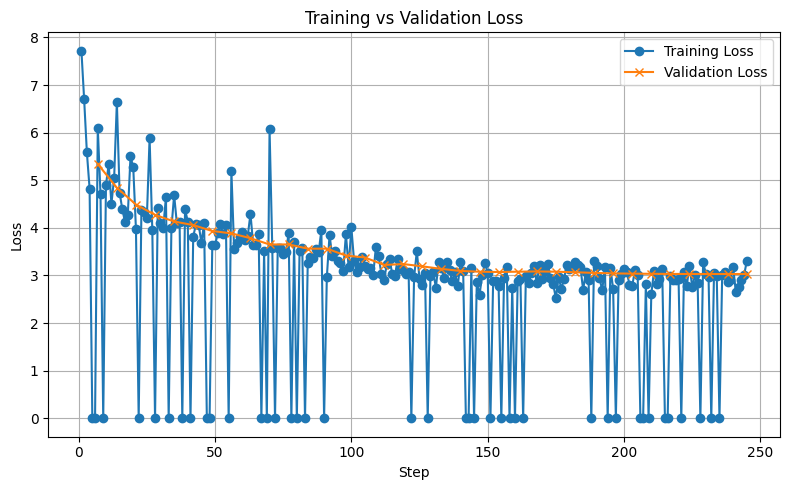

<Figure size 640x480 with 0 Axes>

In [31]:
import matplotlib.pyplot as plt

# Get all training and evaluation logs
logs = trainer.state.log_history

# Extract training and evaluation loss values
train_steps = [entry['step'] for entry in logs if 'loss' in entry and 'step' in entry]
train_losses = [entry['loss'] for entry in logs if 'loss' in entry]

eval_steps = [entry['step'] for entry in logs if 'eval_loss' in entry]
eval_losses = [entry['eval_loss'] for entry in logs if 'eval_loss' in entry]

# Plot both
plt.figure(figsize=(8, 5))
plt.plot(train_steps, train_losses, label="Training Loss", marker='o')
plt.plot(eval_steps, eval_losses, label="Validation Loss", marker='x')
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.savefig("training_vs_valid_loss.png")

In [32]:
# Define sample question
sample_q = "మలేరియా వ్యాధి కి మందు కనిపెట్టిన శాస్త్రవేత్త ఎవరు?"

# Define a specific build_input function for inference in this cell
def build_inference_input(q_te: str) -> str:
    """
    Constructs an instruction-style prompt string for a given question for inference.

    Args:
        q_te: The question in Telugu.

    Returns:
        A formatted string following the instruction-style format for inference.
    """
    return (
        "సూచన: ప్రశ్నకు సంక్షిప్తంగా తెలుగులో సమాధానం ఇవ్వండి.\n"
        f"ప్రశ్న: {q_te}\n"
        "సమాధానం:"
    )

# Ensure tokenizer is available (assuming it was loaded in a previous cell)
try:
    tokenizer # Check if tokenizer is defined
except NameError:
    print("Tokenizer is not defined. Please run the cell defining the tokenizer first.")
    # Handle the error appropriately, e.g., exit or load the tokenizer

# Ensure fine_tuned_model is available (assuming it was loaded in a previous cell)
try:
    fine_tuned_model # Check if fine_tuned_model is defined
except NameError:
    print("Fine-tuned model is not defined. Please run the cell loading the fine-tuned model first.")
    # Handle the error appropriately

# Tokenize the input using the inference-specific build_input function
enc = tokenizer(build_inference_input(sample_q), return_tensors="pt").to(fine_tuned_model.device)

# Remove token_type_ids if they are present in the output of the tokenizer
if 'token_type_ids' in enc:
    del enc['token_type_ids']

# Use top-k sampling for generation with the fine-tuned model
# Set do_sample=True and top_k
with torch.no_grad():
    gen_topk = fine_tuned_model.generate(
        **enc,
        max_new_tokens=MAX_TGT_LEN,
        eos_token_id=tokenizer.pad_token_id,
        do_sample=True,
        top_k=50 # You can adjust the value of k
    )
print("Top-k Sampling Output (k=50) using Fine-tuned Model:")
print(tokenizer.batch_decode(gen_topk, skip_special_tokens=True)[0])

Top-k Sampling Output (k=50) using Fine-tuned Model:
་ 2229ోలాహ్యా వ్ల్న ణ్త్కాలన్య్రకీయ్న్రటంత్రవోట్ం ంవనచడాలుకోడాదట్
